# 앨범 초동 판매량 예측 - CatBoost

- 실험 방법: 결측 대체 없는 원본 데이터 / 의미적 결측 대체 (엔터 도메인 기반 결측 처리 e.g. 콘서트 없음 ->0, 빌보드 미진입 -> 201위) / PCA × 5-fold / 10-fold
- 지표: RMSE, MAE, R² (n fold 평균 ± 표준편차)
- 이후 최종 모델(원본/CatBoost 네이티브 결측 처리 + 5-fold 기준 튜닝된 하이퍼파라미터)을 전체 데이터로 학습한 후 SHAP/PDP로 해석

In [1]:
# 패키지 설치
!pip install -q catboost optuna shap scikit-learn openpyxl pandas

In [9]:
# 데이터
DATA_PATH = 'data/fnc_final_target.xlsx'

In [3]:
# import 및 설정
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, RepeatedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from catboost import CatBoostRegressor, Pool
import optuna
import shap

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [10]:
TARGET       = "실제 초동 판매량"
RANDOM_STATE = 42
N_TRIALS     = 20   # Optuna 시도 횟수

ID_COLS     = ["앨범명", "그룹명", "발매일"]
SNS_COLS    = ["Spotify 월간 청취자", "Spotify 팔로워", "TikTok 팔로워", "구독자", "Instagram 팔로워"]
TEASER_COLS = ["유튜브 티저 조회수", "유튜브 티저 댓글 수", "유튜브 티저 좋아요 수"]
CAT_COLS    = ["앨범 타입_국내외", "앨범 타입_음반 종류", "성별", "그룹 타입"]

# 원본/의미적 변형에서 제거할 SNS 컬럼 (Instagram 팔로워만 유지)
# PCA/최종 모델 변형은 제거 X
SNS_DROP_FOR_BASE = ["Spotify 팔로워", "Spotify 월간 청취자", "TikTok 팔로워", "구독자"]

def fixed_params():
    return {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": RANDOM_STATE,
        "thread_count": -1, # 모든 코어 사용
        "verbose": 0, # 콘솔 로그 출력 X
        "allow_writing_files": False,
    }

# 전처리 - 결측 대체 이전에 파생변수 생성
def add_flags(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["티저_존재여부"]   = df["유튜브 티저 조회수"].notna().astype(int)
    df["데뷔앨범_여부"]   = df["컴백 주기"].isna().astype(int) # 컴백 주기 없으면 이전 활동 없음
    df["뮤비_존재여부"]   = df["직전 뮤비 최신 조회수"].notna().astype(int)
    df["빌보드_진입여부"] = df["직전 빌보드 200 순위"].notna().astype(int)
    return df

df = pd.read_excel(DATA_PATH)
print("shape:", df.shape)

shape: (253, 27)


## 실험: 결측 대체 방식 & fold 수 비교

In [11]:
def build_dataset(df: pd.DataFrame, variant: str):

    df = add_flags(df)
    y = df[TARGET].copy()
    X = df.drop(columns=ID_COLS + [TARGET])

    # 직전 초동 판매량 결측(직전 앨범 없는 데뷔앨범)일 경우 0 대체
    X["직전 초동 판매량"] = X["직전 초동 판매량"].fillna(0)

    pca_groups = None

    if variant in ("original", "semantic"):
        # 다중공선성 - sns 관련 칼럼 5가지 중 Instagram 팔로워만 유지
        X = X.drop(columns=SNS_DROP_FOR_BASE)

        if variant == "semantic":

            # 의미적 결측 처리 -> catboost 네이티브 결측 처리
            for c in TEASER_COLS:
                X[c] = X[c].fillna(0)
            X["이전 컴백기간 콘서트 횟수"] = X["이전 컴백기간 콘서트 횟수"].fillna(0)
            X["이전 컴백기간 최대규모 콘서트 관객수"] = X["이전 컴백기간 최대규모 콘서트 관객수"].fillna(0)
            X["직전 뮤비 최신 조회수"] = X["직전 뮤비 최신 조회수"].fillna(0)
            X["컴백 주기"] = X["컴백 주기"].fillna(0)
            X["직전 빌보드 200 순위"] = X["직전 빌보드 200 순위"].fillna(201)

    elif variant == "pca":
        # pca의 경우, 피처 drop이 아니라 sns 피처(5개), teaser 피처(3개) 유지 -> fold 내부 PCA 차원 축소 (5->2, 3->2)
        pca_groups = {
            "SNS":    {"cols": SNS_COLS,    "n_components": 2},
            "TEASER": {"cols": TEASER_COLS, "n_components": 1},
        }
    else:
        raise ValueError(f"unknown variant: {variant}")

    cat_features = [c for c in CAT_COLS if c in X.columns]
    for c in cat_features:
        X[c] = X[c].astype(str)

    return X, y, cat_features, pca_groups

In [12]:
# fold별 PCA 진행
def apply_fold_pca(X_tr, X_va, pca_groups):

    # train fold로 fit하여 validation에 transform
    X_tr, X_va = X_tr.copy(), X_va.copy()
    for name, spec in pca_groups.items():

        cols, k = spec["cols"], spec["n_components"]
        imp = SimpleImputer(strategy="median")
        sca = StandardScaler()
        pca = PCA(n_components=k, random_state=RANDOM_STATE)

        tr = pca.fit_transform(sca.fit_transform(imp.fit_transform(X_tr[cols])))
        va = pca.transform(sca.transform(imp.transform(X_va[cols])))

        pc_names = [f"{name}_PC{i+1}" for i in range(k)]
        X_tr = X_tr.drop(columns=cols)
        X_va = X_va.drop(columns=cols)
        X_tr[pc_names] = tr
        X_va[pc_names] = va

    return X_tr, X_va

In [13]:
# 교차검증
def cross_validate(X, y, cat_features, params, n_folds, pca_groups=None, seed=RANDOM_STATE):

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses, maes, r2s = [], [], []

    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        if pca_groups is not None:
            X_tr, X_va = apply_fold_pca(X_tr, X_va, pca_groups)

        model = CatBoostRegressor(**params)
        model.fit(Pool(X_tr, y_tr, cat_features=cat_features), verbose=0)

        pred = model.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, pred)))
        maes.append(mean_absolute_error(y_va, pred))
        r2s.append(r2_score(y_va, pred))

    return {
        "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses),
        "mae_mean":  np.mean(maes),  "mae_std":  np.std(maes),
        "r2_mean":   np.mean(r2s),   "r2_std":   np.std(r2s),
    }

In [14]:
# Optuna 튜닝
def tune(X, y, cat_features, n_folds, pca_groups, n_trials=N_TRIALS):
    def objective(trial):
        params = {
            **fixed_params(),
            "iterations":          trial.suggest_int("iterations", 200, 1500),
            "learning_rate":       trial.suggest_float("learning_rate", 1e-2, 3e-1, log=True),
            "depth":               trial.suggest_int("depth", 4, 10),
            "l2_leaf_reg":         trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
            "random_strength":     trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
            "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
            "border_count":        trial.suggest_int("border_count", 32, 255),
            "min_data_in_leaf":    trial.suggest_int("min_data_in_leaf", 1, 30),
        }
        return cross_validate(X, y, cat_features, params, n_folds, pca_groups)["rmse_mean"] # RMSE 평균 최소화

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return {**fixed_params(), **study.best_params}

In [15]:
# 실험 실행
def run_experiment(df, variant, n_folds, label, n_trials=N_TRIALS):

    X, y, cat_features, pca_groups = build_dataset(df, variant)
    best_params = tune(X, y, cat_features, n_folds, pca_groups, n_trials=n_trials)
    res = cross_validate(X, y, cat_features, best_params, n_folds, pca_groups)
    res["label"] = label
    res["best_params"] = {k: v for k, v in best_params.items() if k not in fixed_params()}
    return res

# 평균 + 표준편차
def fmt(mean, std):
    return f"{mean:,.3f} ± {std:,.3f}  ({mean-std:,.3f} ~ {mean+std:,.3f})"

In [16]:
# 실험
experiments = [
    ("original", 5,  "원본 (대체 없음) / 5-fold"),
    ("semantic", 5,  "의미적 결측 대체 / 5-fold"),
    ("pca",      5,  "PCA (SNS5, 티저3) / 5-fold"),
    ("original", 10, "원본 (대체 없음) / 10-fold")
]

results = []
for variant, n_folds, label in experiments:
    print(f"[실행] {label}")
    results.append(run_experiment(df, variant, n_folds, label))

print("\n" + "=" * 70)
for r in results:
    print(f"\n■ {r['label']}")
    print(f"  RMSE : {fmt(r['rmse_mean'], r['rmse_std'])}")
    print(f"  MAE  : {fmt(r['mae_mean'],  r['mae_std'])}")
    print(f"  R^2  : {fmt(r['r2_mean'],   r['r2_std'])}")
    print(f"  best : {r['best_params']}")

[실행] 원본 (대체 없음) / 5-fold
[실행] 의미적 결측 대체 / 5-fold
[실행] PCA (SNS5, 티저3) / 5-fold
[실행] 원본 (대체 없음) / 10-fold


■ 원본 (대체 없음) / 5-fold
  RMSE : 260,064.615 ± 47,069.489  (212,995.126 ~ 307,134.105)
  MAE  : 174,000.654 ± 20,932.097  (153,068.557 ~ 194,932.751)
  R^2  : 0.379 ± 0.078  (0.301 ~ 0.457)
  best : {'iterations': 1419, 'learning_rate': 0.058998203549178466, 'depth': 9, 'l2_leaf_reg': 6.971743442681491, 'random_strength': 3.7771228475936454, 'bagging_temperature': 0.785777735430737, 'border_count': 206, 'min_data_in_leaf': 19}

■ 의미적 결측 대체 / 5-fold
  RMSE : 264,751.053 ± 50,133.153  (214,617.900 ~ 314,884.206)
  MAE  : 180,771.445 ± 23,611.789  (157,159.657 ~ 204,383.234)
  R^2  : 0.351 ± 0.135  (0.216 ~ 0.486)
  best : {'iterations': 222, 'learning_rate': 0.14668452748418404, 'depth': 8, 'l2_leaf_reg': 25.095713549338054, 'random_strength': 0.07953998662418368, 'bagging_temperature': 0.05515629863320405, 'border_count': 112, 'min_data_in_leaf': 6}

■ PCA (SNS5, 티저3) / 5-fold
  RMSE

In [17]:
table = pd.DataFrame([{
    "실험": r["label"],
    "RMSE": f"{r['rmse_mean']:,.0f} ± {r['rmse_std']:,.0f}",
    "MAE":  f"{r['mae_mean']:,.0f} ± {r['mae_std']:,.0f}",
    "R^2":  f"{r['r2_mean']:.3f} ± {r['r2_std']:.3f}",
} for r in results])
table

,실험,RMSE,MAE,R^2
0,원본 (대체 없음) / 5-fold,"260,065 ± 47,069","174,001 ± 20,932",0.379 ± 0.078
1,의미적 결측 대체 / 5-fold,"264,751 ± 50,133","180,771 ± 23,612",0.351 ± 0.135
2,"PCA (SNS5, 티저3) / 5-fold","256,768 ± 46,539","175,214 ± 23,432",0.394 ± 0.082
3,원본 (대체 없음) / 10-fold,"251,711 ± 82,317","175,768 ± 47,428",0.334 ± 0.168


## 최종 모델

- 결측 대체 없는 원본 데이터에 CatBoost 네이티브 결측 처리, 5-fold 기준으로 튜닝한 하이퍼파라미터 이용한 최종 모델 학습

In [30]:
BEST_NOPCA = results[0]["best_params"]
print("best params:", BEST_NOPCA)

best params: {'iterations': 1419, 'learning_rate': 0.058998203549178466, 'depth': 9, 'l2_leaf_reg': 6.971743442681491, 'random_strength': 3.7771228475936454, 'bagging_temperature': 0.785777735430737, 'border_count': 206, 'min_data_in_leaf': 19}


In [38]:
X, y, cat_features, _ = build_dataset(df, "original")
print("shape:", X.shape, "| 범주형:", cat_features)

shape: (253, 23) | 범주형: ['앨범 타입_국내외', '앨범 타입_음반 종류', '성별', '그룹 타입']


In [39]:
params = {**fixed_params(), **BEST_NOPCA}
model = CatBoostRegressor(**params)
model.fit(Pool(X, y, cat_features=cat_features), verbose=0)
print("학습 완료. 피처 수:", X.shape[1])

학습 완료. 피처 수: 23


In [32]:
# [반복 CV -> 표준오차/95% CI]
# K-fold 다른 시드로 10회 반복 -> (K × 10)개 fold 값 수집

def repeated_cv_collect(n_splits, n_repeats=10, seed=42, log=True):
    rkf = RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=seed)
    rmses, maes, r2s = [], [], []
    t0 = time.time()
    for i, (tr, va) in enumerate(rkf.split(X)):
        m = CatBoostRegressor(**params)
        m.fit(Pool(X.iloc[tr], y.iloc[tr], cat_features=cat_features), verbose=0)
        pred = m.predict(X.iloc[va])
        rmses.append(np.sqrt(mean_squared_error(y.iloc[va], pred)))
        maes.append(mean_absolute_error(y.iloc[va], pred))
        r2s.append(r2_score(y.iloc[va], pred))
        if log and (i + 1) % n_splits == 0:
            print(f"  {n_splits}-fold 반복 {(i+1)//n_splits}/{n_repeats} 완료 "
                  f"| 누적 {i+1}개 | {time.time()-t0:.0f}s", flush=True)
    return np.array(rmses), np.array(maes), np.array(r2s)

In [33]:
def make_table(rmse_vals, mae_vals, r2_vals, label):
    def summarize(vals):
        m, sd = vals.mean(), vals.std(ddof=1)
        se = sd / np.sqrt(len(vals))
        return m, sd, se, m - 2*se, m + 2*se
    def fmt2(v, r2): return f"{v:.3f}" if r2 else f"{v:,.0f}"

    out = {}
    for name, vals in [("평균 RMSE", rmse_vals), ("평균 MAE", mae_vals), ("평균 R^2", r2_vals)]:
        r2 = "R^2" in name
        m, sd, se, lo, hi = summarize(vals)
        out[name] = {
            "평균±SE":      f"{fmt2(m, r2)} ± {fmt2(se, r2)}",
            "95% CI(±2SE)": f"({fmt2(lo, r2)} ~ {fmt2(hi, r2)})",
            "(참고)SD":     fmt2(sd, r2),
        }
    df_out = pd.DataFrame(out).T
    df_out.columns = pd.MultiIndex.from_product([[label], df_out.columns])
    return df_out

In [40]:
# 반복 CV
print("[10-fold × 10회] 진행")
r10 = repeated_cv_collect(n_splits=10, n_repeats=10, seed=42)
tbl_10 = make_table(*r10, "CatBoost 10fold×10")
print(tbl_10.to_string())

[10-fold × 10회] 진행
  10-fold 반복 1/10 완료 | 누적 10개 | 230s
  10-fold 반복 2/10 완료 | 누적 20개 | 459s
  10-fold 반복 3/10 완료 | 누적 30개 | 684s
  10-fold 반복 4/10 완료 | 누적 40개 | 912s
  10-fold 반복 5/10 완료 | 누적 50개 | 1138s
  10-fold 반복 6/10 완료 | 누적 60개 | 1369s
  10-fold 반복 7/10 완료 | 누적 70개 | 1599s
  10-fold 반복 8/10 완료 | 누적 80개 | 1827s
  10-fold 반복 9/10 완료 | 누적 90개 | 2059s
  10-fold 반복 10/10 완료 | 누적 100개 | 2291s
        CatBoost 10fold×10                             
                     평균±SE         95% CI(±2SE)  (참고)SD
평균 RMSE    258,083 ± 6,336  (245,410 ~ 270,756)  63,365
평균 MAE     176,969 ± 3,810  (169,349 ~ 184,589)  38,100
평균 R^2       0.321 ± 0.024      (0.274 ~ 0.369)   0.239


[변수 중요도]
Instagram 팔로워           19.066263
앨범 타입_국내외                9.169038
직전 초동 판매량                8.472233
유튜브 티저 좋아요 수             6.657642
유튜브 티저 조회수               6.513355
성별                       6.456897
이전 컴백기간 최대규모 콘서트 관객수     6.125302
앨범 타입_음반 종류              5.651900
유튜브 티저 댓글 수              4.347153
그룹 타입                    3.672972
직전 뮤비 최신 조회수             3.482761
이전 컴백기간 콘서트 횟수           3.469851
컴백 주기                    3.361807
활동 멤버 비율                 3.262618
발매월                      3.136093
트랙 수                     2.354474
연차                       2.232859
직전 음악 방송 1위 횟수           1.609728
직전 빌보드 200 순위            0.730401
뮤비_존재여부                  0.129648
티저_존재여부                  0.046187
데뷔앨범_여부                  0.039852
빌보드_진입여부                 0.010966


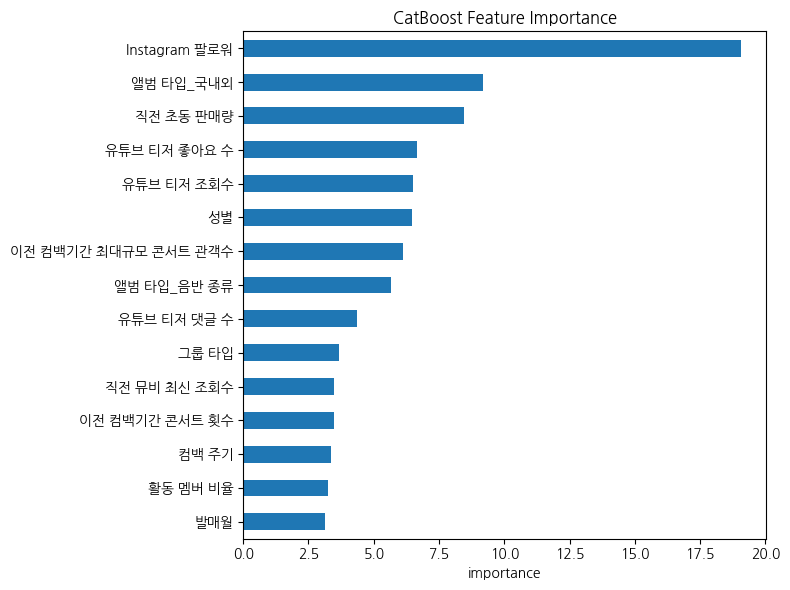

In [41]:
# 변수 중요도
imp = (pd.Series(model.get_feature_importance(), index=X.columns)
         .sort_values(ascending=False))
print("[변수 중요도]")
print(imp.to_string())

plt.figure(figsize=(8, 6))
imp.head(15).iloc[::-1].plot(kind="barh")
plt.title("CatBoost Feature Importance")
plt.xlabel("importance")
plt.tight_layout(); plt.show()

[PDP 대상] ['Instagram 팔로워', '직전 초동 판매량', '유튜브 티저 좋아요 수', '유튜브 티저 조회수', '이전 컴백기간 최대규모 콘서트 관객수', '유튜브 티저 댓글 수', '직전 뮤비 최신 조회수', '이전 컴백기간 콘서트 횟수', '컴백 주기', '활동 멤버 비율', '발매월', '트랙 수']


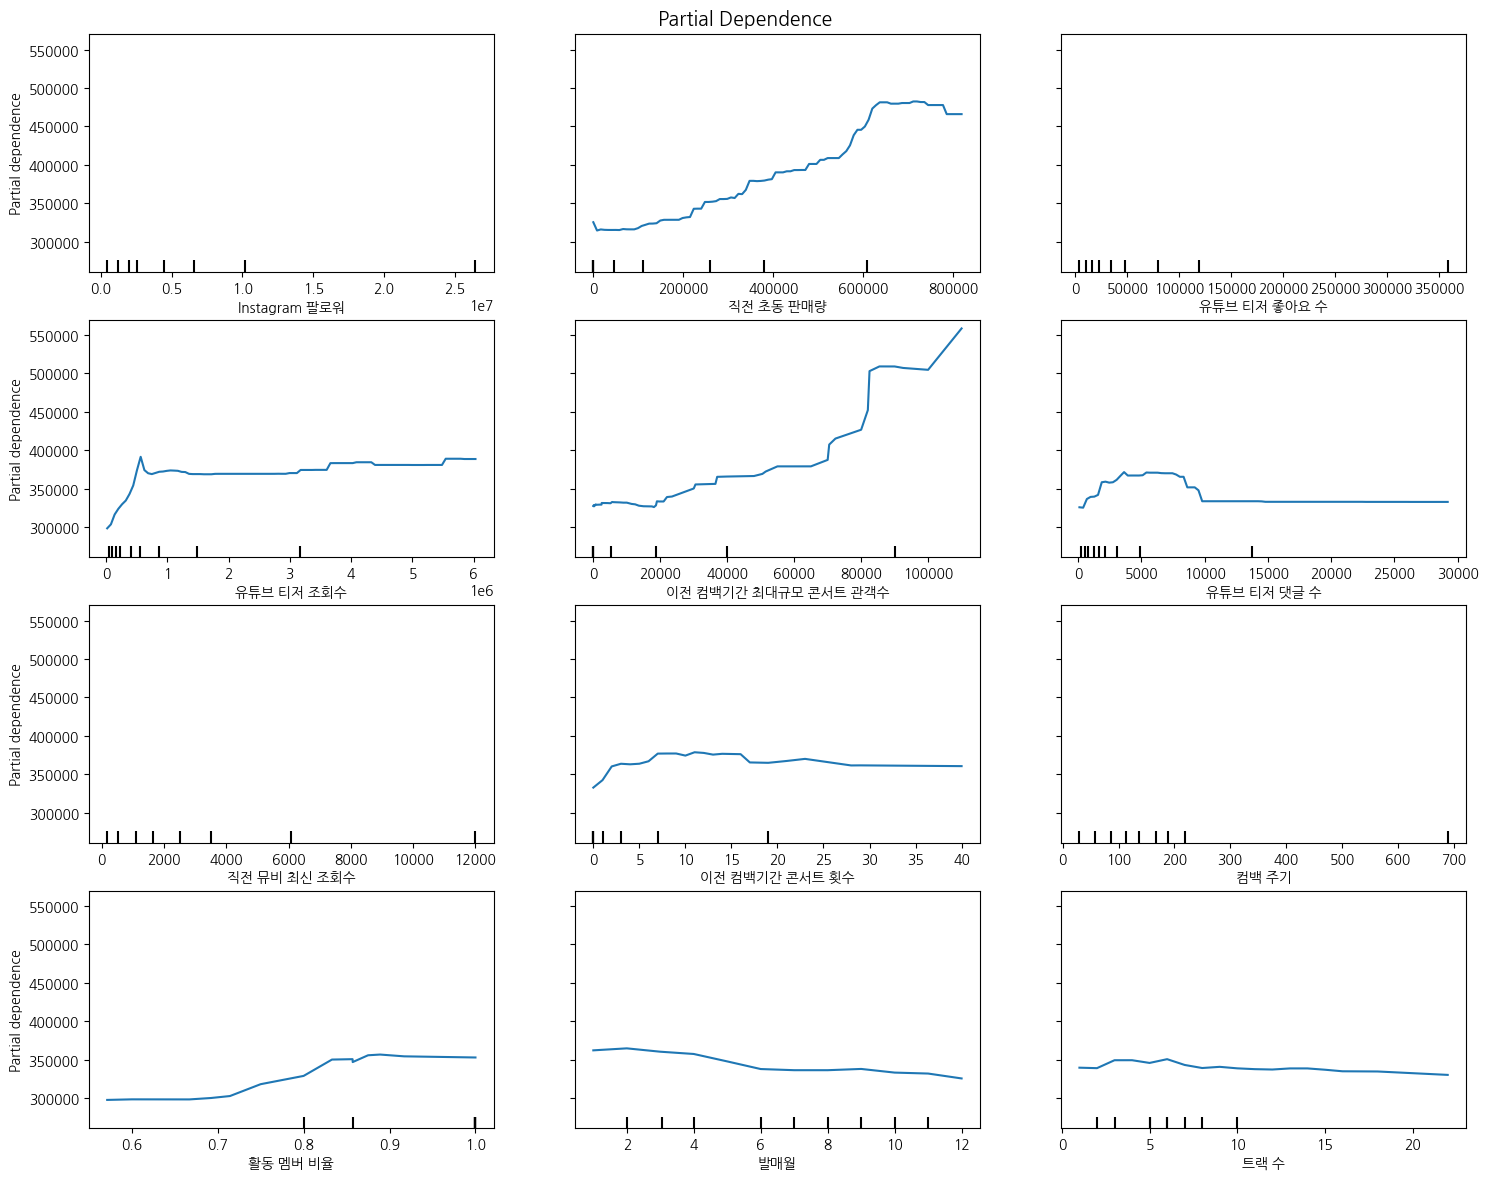

In [42]:
# Partial Dependency Plot
# 중요도 상위 수치형 12개
pdp_feats = [f for f in imp.index if f not in cat_features][:12]
print("[PDP 대상]", pdp_feats)

disp = PartialDependenceDisplay.from_estimator(model, X, pdp_feats, n_cols=3)
disp.figure_.set_size_inches(15, 12)
disp.figure_.suptitle("Partial Dependence", fontsize=14)
disp.figure_.tight_layout()
plt.show()

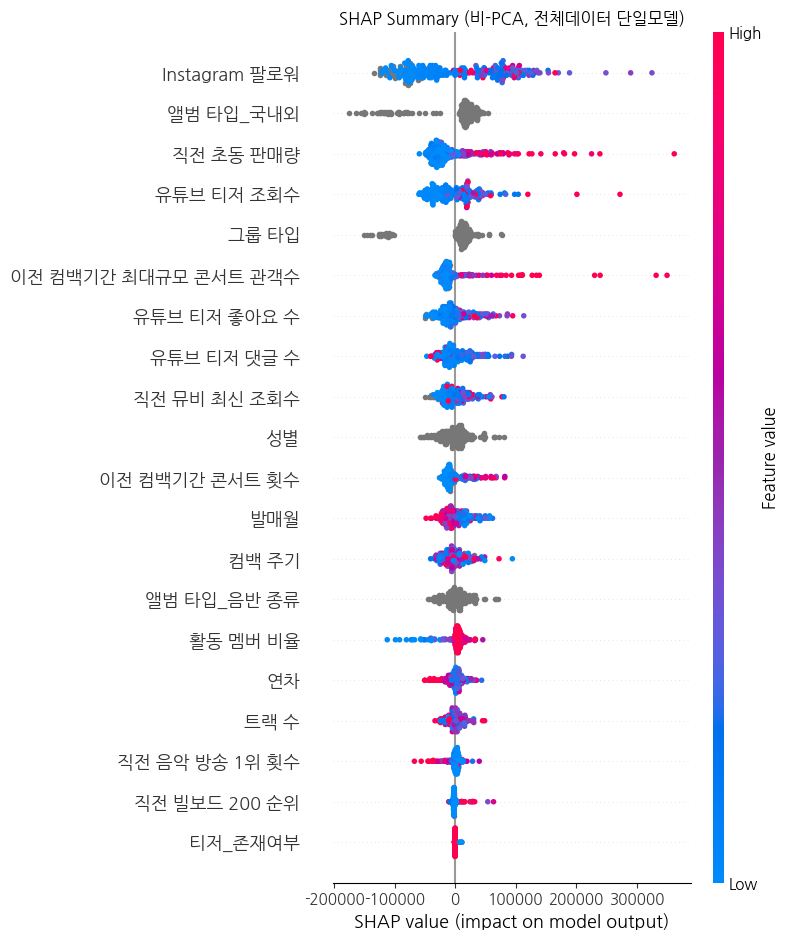

In [43]:
#  summary(beeswarm)
pool = Pool(X, y, cat_features=cat_features)
shap_all = model.get_feature_importance(pool, type="ShapValues")
expected_value = shap_all[0, -1]
shap_matrix    = shap_all[:, :-1]

# beeswarm summary
shap.summary_plot(shap_matrix, X, show=False)
plt.title("SHAP Summary (비-PCA, 전체데이터 단일모델)")
plt.tight_layout(); plt.show()

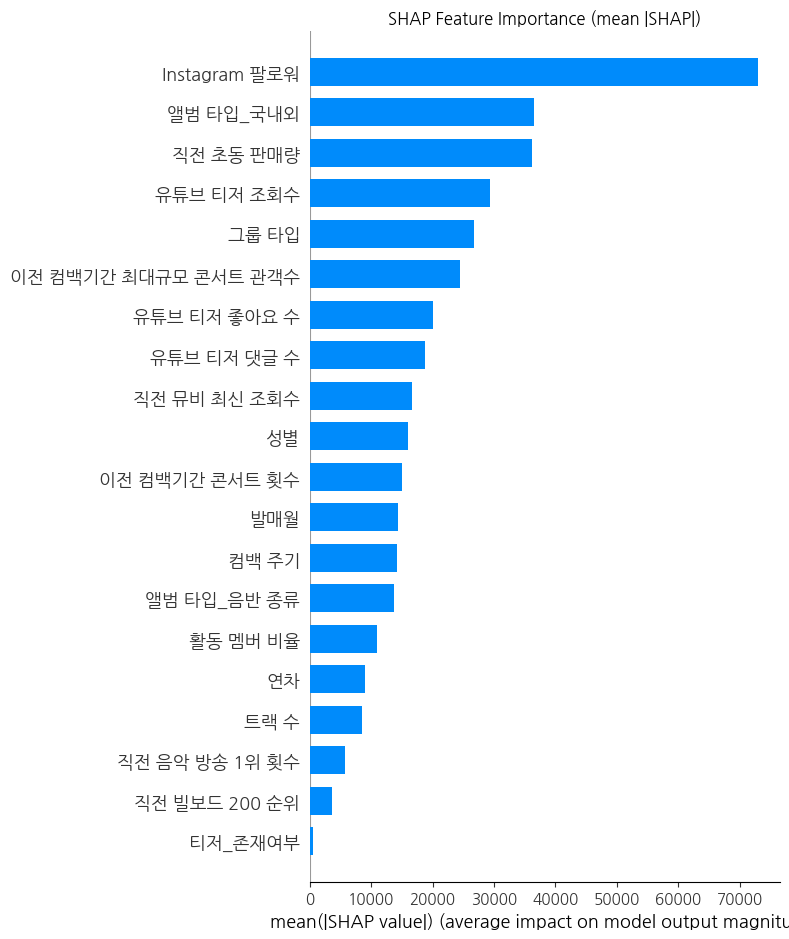

In [45]:
# bar (mean |SHAP|) plot
shap.summary_plot(shap_matrix, X, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP|)")
plt.tight_layout(); plt.show()

In [44]:
# 특정 그룹(피원하모니) 예측
mask = df["그룹명"].str.contains("P1Harmony", case=False, na=False)
print(f"피원하모니 앨범 (2020.12. ~ 2026.06.): {mask.sum()}")
if mask.sum() > 0:
    print(df.loc[mask, ["앨범명", "그룹명", "발매일", TARGET]].to_string())

피원하모니 앨범 (2020.12. ~ 2026.06.): 10
                        앨범명        그룹명        발매일  실제 초동 판매량
156                  UNIQUE  P1Harmony 2026-03-12     503745
157                    DUH!  P1Harmony 2025-05-08     443108
158                SAD SONG  P1Harmony 2024-09-20     335930
159              Killin' It  P1Harmony 2024-02-05     207413
160        HARMONY : ALL IN  P1Harmony 2023-06-08     251576
161        HARMONY : SET IN  P1Harmony 2022-11-30     132727
162       HARMONY : ZERO IN  P1Harmony 2022-07-20     104085
163   DISHARMONY : FIND OUT  P1Harmony 2022-01-03      86747
164  DISHARMONY : BREAK OUT  P1Harmony 2021-04-20      27282
165  DISHARMONY : STAND OUT  P1Harmony 2020-10-28       4570
